In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import numpy as np

X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_repeated=0,
                           random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=2)
model = LogisticRegression().fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, proba)

gmean = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmean)

print(f'Best threshold = {thresholds[ix]:.3f}')
print(f'TPR = {tpr[ix]:.3f}, FPR = {fpr[ix]:.3f}, mean = {gmean[ix]:.3f}')

Best threshold = 0.452
TPR = 0.895, FPR = 0.195, mean = 0.849


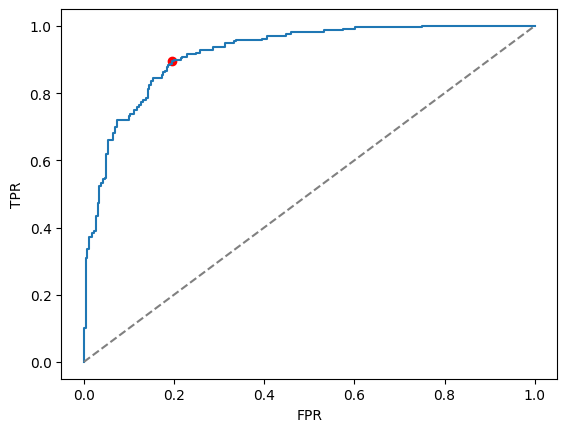

In [6]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label='ROC curve')
plt.scatter(fpr[ix], tpr[ix], c='red', label='optimal mean')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.show()

In [7]:
y_pred = (proba >= thresholds[ix]).astype(int)
y_pred

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,